Calculando 10000 dígitos de e (Euler)...


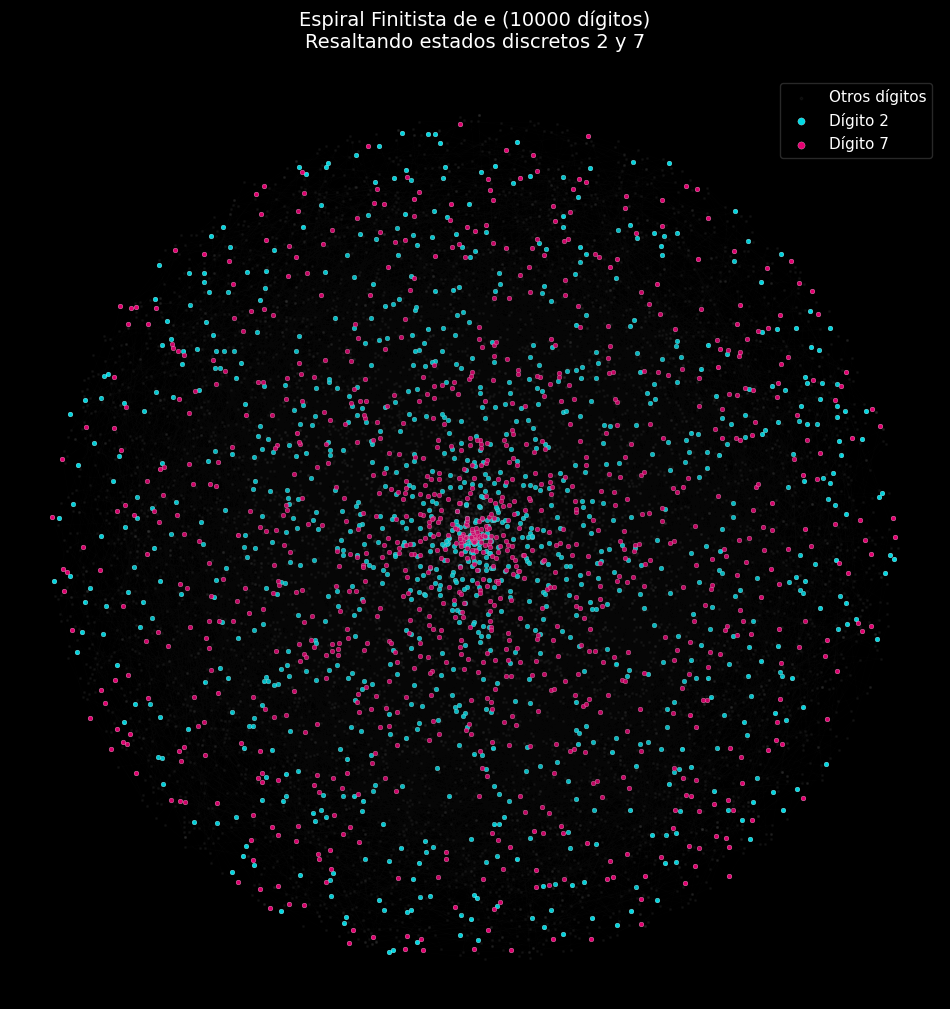

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpmath import mp

# --- CONFIGURACIÓN DE E ---
CANTIDAD_DIGITOS = 10000
mp.dps = CANTIDAD_DIGITOS + 5

print(f"Calculando {CANTIDAD_DIGITOS} dígitos de e (Euler)...")

# Extraer dígitos de e limpiando el punto decimal
e_str = str(mp.e).replace('.', '')[:CANTIDAD_DIGITOS]
digitos = np.array([int(d) for d in e_str])

# Coordenadas polares acumulativas
r = np.arange(CANTIDAD_DIGITOS)
theta = np.cumsum(digitos) - digitos

x = r * np.cos(theta)
y = r * np.sin(theta)

# Máscaras de aislamiento (Dígitos 2 y 7)
es_dos = (digitos == 2)
es_siete = (digitos == 7)
otros_digitos = ~(es_dos | es_siete)

# Renderizado Finitista
plt.figure(figsize=(12, 12), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.plot(x, y, color='#222222', linewidth=0.15, alpha=0.2)
plt.scatter(x[otros_digitos], y[otros_digitos], color='#444444', s=1.5, alpha=0.15, label='Otros dígitos')
plt.scatter(x[es_dos], y[es_dos], color='#00f3ff', s=12, alpha=0.9, edgecolors='white', linewidths=0.2, label='Dígito 2')
plt.scatter(x[es_siete], y[es_siete], color='#ff007f', s=12, alpha=0.9, edgecolors='white', linewidths=0.2, label='Dígito 7')

plt.title(f"Espiral Finitista de e ({CANTIDAD_DIGITOS} dígitos)\nResaltando estados discretos 2 y 7", color='white', fontsize=14, pad=20)
plt.axis('equal')
plt.axis('off')
plt.legend(facecolor='black', edgecolor='#333333', loc='upper right', fontsize=11, labelcolor='white', markerscale=1.5)
plt.show()
